In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# STEP 1: INSTALL LIBRARIES
# =======================================================================
!pip uninstall -y numpy pandas scikit-learn umap-learn
!pip install numpy pandas scikit-learn umap-learn lightgbm
!pip install -q sentence-transformers hdbscan bertopic gensim vaderSentiment shap networkx spacy imbalanced-learn
!python -m spacy download en_core_web_sm -q

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.3.3
Uninstalling pandas-2.3.3:
  Successfully uninstalled pandas-2.3.3
Found existing installation: scikit-learn 1.7.2
Uninstalling scikit-learn-1.7.2:
  Successfully uninstalled scikit-learn-1.7.2
Found existing installation: umap-learn 0.5.9.post2
Uninstalling umap-learn-0.5.9.post2:
  Successfully uninstalled umap-learn-0.5.9.post2
  Using cached numpy-2.3.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached umap_learn-0.5.9.post2-py3-none-any.whl.metadata (25 kB)
  Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached pandas-2.3.3

^C


In [ ]:
!pip install --upgrade --force-reinstall numpy==1.26.4 gensim==4.3.3


  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached gensim-4.3.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached scipy-1.13.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached smart_open-7.4.1-py3-none-any.whl.metadata (24 kB)
  Using cached wrapt-2.0.0-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (8.8 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached gensim-4.3.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.6 MB)
Using cached scipy-1.13.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.2 MB)
Using cached smart_open-7.4.1-py3-none-any.whl (63 kB)
Using cached wrapt-2.0.0-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl (121 kB)
  Attempting uninstall: wrapt
    Found existing

In [ ]:
# STEP 2: IMPORT LIBRARIES
# =======================================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import pickle, re
from pathlib import Path

# NLP
import nltk, spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# Embeddings
from sentence_transformers import SentenceTransformer

# Topic modeling
from gensim import corpora
from gensim.models import LdaModel

# Network
import networkx as nx

# Sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score
from imblearn.combine import SMOTETomek
import lightgbm as lgb

# Visualization
import shap
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries installed and imported successfully!\n")

✅ All libraries installed and imported successfully!



In [ ]:
# STEP 3: UPLOAD DATASET
# =======================================================================
from google.colab import files

print("📂 Please upload your 'NLP dataset.csv' file:")
uploaded = files.upload()

dataset_filename = list(uploaded.keys())[0]
print(f"✅ File uploaded: {dataset_filename}\n")

# Inspect dataset
df_inspect = pd.read_csv(dataset_filename)
print("📊 Dataset Information:")
print(f"Shape: {df_inspect.shape}")
print(f"Columns: {df_inspect.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_inspect.head())
print(f"\nLabel distribution:")
print(df_inspect['risk_level'].value_counts())

# Auto-detect columns
text_column = 'text'
label_column = 'risk_level'
print(f"\n✅ Using columns: text='{text_column}', label='{label_column}'")

📂 Please upload your 'NLP dataset.csv' file:


Saving NLP dataset.csv to NLP dataset.csv
✅ File uploaded: NLP dataset.csv

📊 Dataset Information:
Shape: (13248, 2)
Columns: ['text', 'risk_level']

First few rows:
                                                text   risk_level
0  Friend is in psychiatric hospital. Need advice...     low risk
1  meaninglessi was forced to move to a different...  medium risk
2  Just fvcking kill meBack in October I was kick...     low risk
3  It was only a matter of timeIâve been abused...     low risk
4  I just canât hold it anymoreYes, new year, n...  medium risk

Label distribution:
risk_level
low risk       3312
medium risk    3312
no risk        3312
high risk      3312
Name: count, dtype: int64

✅ Using columns: text='text', label='risk_level'


In [ ]:
# STAGE 1: DATA PREPROCESSING
# =======================================================================
class DataPreprocessor:
    def __init__(self):
        self.stopwords = set(stopwords.words('english'))

    def clean_text(self, text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        text = re.sub(r'@\w+|#\w+', '', text)
        text = re.sub(r'[^a-z\s.,!?]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def preprocess_dataset(self, df, text_col='text', label_col='risk_level'):
        print("🔄 Preprocessing dataset...")
        df = df.copy()
        df = df.dropna(subset=[text_col, label_col])
        df['cleaned_text'] = df[text_col].apply(self.clean_text)
        df = df[df['cleaned_text'].str.len() > 10]
        df = df.reset_index(drop=True)
        print(f"✅ Preprocessing complete: {len(df)} samples\n")
        return df

In [ ]:
# =======================================================================
# STAGE 2: FEATURE EXTRACTION (COMPATIBLE WITH PIPELINE)
# Replace your existing FeatureExtractor cell with this cell.
# =======================================================================

import numpy as np
import pandas as pd
import nltk, spacy, networkx as nx
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from gensim import corpora
from gensim.models import LdaModel
from sentence_transformers import SentenceTransformer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ensure basic NLTK downloads (safe-no-op if already present)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('stopwords', quiet=True)

class FeatureExtractor:
    def __init__(self, embed_model_name='all-mpnet-base-v2', lda_topics=10):
        print("🔧 Initializing FeatureExtractor...")
        # Embeddings model
        self.embed_model = SentenceTransformer(embed_model_name)
        # Sentiment
        self.sia = SentimentIntensityAnalyzer()
        # spaCy for cognitive graph
        try:
            self.nlp = spacy.load('en_core_web_sm')
        except:
            # If spaCy model not loaded, try to load later or instruct user to run download cell
            self.nlp = None
        # LDA placeholders
        self.lda_model = None
        self.dictionary = None
        self.lda_topics = lda_topics
        print("✅ FeatureExtractor ready\n")

    # ---------------------------
    # Embeddings
    # ---------------------------
    def get_embeddings(self, texts, batch_size=32):
        """texts: iterable (list/Series) of raw strings -> returns numpy array (n_samples, embed_dim)"""
        if isinstance(texts, (pd.Series, np.ndarray, list)):
            texts_list = list(texts)
        else:
            texts_list = [texts]
        print("📊 Generating transformer embeddings...")
        embeddings = self.embed_model.encode(texts_list, show_progress_bar=False, batch_size=batch_size)
        return np.array(embeddings)

    # ---------------------------
    # Sentiment (VADER)
    # ---------------------------
    def get_sentiment_features(self, texts):
        """Return array (n_samples, 4): neg, neu, pos, compound"""
        print("😊 Extracting sentiment features...")
        out = []
        for t in texts:
            if not isinstance(t, str) or t.strip() == "":
                out.append([0.0, 0.0, 0.0, 0.0])
                continue
            s = self.sia.polarity_scores(t)
            out.append([s['neg'], s['neu'], s['pos'], s['compound']])
        return np.array(out)

    # ---------------------------
    # Linguistic features (simple)
    # ---------------------------
    def get_linguistic_features(self, texts):
        """Examples: word_count, avg_word_len, death_word_ratio, neg_word_ratio, first_person_ratio, exclam_ratio, question_ratio, lexical_diversity"""
        print("📝 Extracting linguistic features...")
        death_words = {'die', 'death', 'suicide', 'kill', 'dead', 'dying', 'end'}
        negative_words = {'sad', 'hopeless', 'worthless', 'alone', 'hurt', 'pain', 'depressed', 'lonely', 'empty', 'numb', 'broken'}
        first_person = {'i', 'me', 'my', 'mine', 'myself'}
        rows = []
        for text in texts:
            if not isinstance(text, str) or text.strip() == "":
                rows.append([0]*8)
                continue
            words = [w.lower() for w in word_tokenize(text) if w.isalpha()]
            word_count = max(len(words), 1)
            avg_len = np.mean([len(w) for w in words]) if words else 0
            death_ratio = sum(1 for w in words if w in death_words)/word_count
            neg_ratio = sum(1 for w in words if w in negative_words)/word_count
            fp_ratio = sum(1 for w in words if w in first_person)/word_count
            exclam_ratio = text.count('!')/word_count
            quest_ratio = text.count('?')/word_count
            lexical_div = len(set(words))/word_count
            rows.append([word_count, avg_len, death_ratio, neg_ratio, fp_ratio, exclam_ratio, quest_ratio, lexical_div])
        return np.array(rows)

    # ---------------------------
    # POS features
    # ---------------------------
    def get_pos_features(self, texts):
        """Returns normalized counts for noun, verb, adj, adv, pronoun, prep -> shape (n,6)"""
        print("🏷️  Extracting POS tag features...")
        out = []
        for text in texts:
            try:
                if not isinstance(text, str) or text.strip() == "":
                    out.append([0]*6)
                    continue
                tokens = word_tokenize(text)
                tags = pos_tag(tokens)
                pos_counts = {'noun':0,'verb':0,'adj':0,'adv':0,'pronoun':0,'prep':0}
                for _, tag in tags:
                    if tag.startswith('NN'): pos_counts['noun'] += 1
                    elif tag.startswith('VB'): pos_counts['verb'] += 1
                    elif tag.startswith('JJ'): pos_counts['adj'] += 1
                    elif tag.startswith('RB'): pos_counts['adv'] += 1
                    elif tag.startswith('PR'): pos_counts['pronoun'] += 1
                    elif tag.startswith('IN'): pos_counts['prep'] += 1
                total = max(len(tokens), 1)
                out.append([pos_counts[k]/total for k in ['noun','verb','adj','adv','pronoun','prep']])
            except Exception:
                out.append([0]*6)
        return np.array(out)

    # ---------------------------
    # Topic modeling (LDA) - safe behavior
    # ---------------------------
    def get_topic_features(self, texts, n_topics=None, no_below=5, no_above=0.5):
        """Return (n_samples, n_topics) topic distributions.
           If LDA not trained yet, it will try to train on the passed 'texts' (a list/Series).
           If training is not possible (too few tokens), returns zero vectors.
        """
        n_topics = n_topics or self.lda_topics
        print(f"📚 Extracting topic features (LDA with {n_topics} topics)...")
        # prepare tokenized texts
        tokenized = []
        for t in texts:
            if not isinstance(t, str) or t.strip()=="":
                tokenized.append([])
            else:
                tokenized.append([w.lower() for w in word_tokenize(t) if w.isalpha()])

        # If we don't yet have a trained LDA model, attempt to train using non-empty docs
        if self.lda_model is None:
            nonempty = [doc for doc in tokenized if len(doc) > 0]
            if len(nonempty) == 0:
                # nothing to train on
                print("⚠️ No valid documents to train LDA on — returning zero topic vectors.")
                return np.zeros((len(texts), n_topics))
            self.dictionary = corpora.Dictionary(nonempty)
            # filter extremes (safe)
            try:
                self.dictionary.filter_extremes(no_below=no_below, no_above=no_above)
            except Exception:
                pass
            if len(self.dictionary) == 0:
                print("⚠️ Dictionary empty after filtering — returning zero topic vectors.")
                return np.zeros((len(texts), n_topics))
            corpus = [self.dictionary.doc2bow(doc) for doc in nonempty]
            try:
                self.lda_model = LdaModel(corpus=corpus, id2word=self.dictionary, num_topics=n_topics,
                                          random_state=42, passes=10, per_word_topics=False)
            except Exception as e:
                print("⚠️ LDA training failed:", e)
                self.lda_model = None
                return np.zeros((len(texts), n_topics))

        # Now compute distributions for each document safely
        topic_features = []
        for doc in tokenized:
            if self.lda_model is None or len(doc) == 0:
                topic_features.append([0.0]*n_topics)
                continue
            bow = self.dictionary.doc2bow(doc)
            if len(bow) == 0:
                topic_features.append([0.0]*n_topics)
                continue
            # get_document_topics with minimum_probability=0 ensures full-length vector
            dist = dict(self.lda_model.get_document_topics(bow, minimum_probability=0))
            # order by topic id
            vec = [float(dist.get(i, 0.0)) for i in range(n_topics)]
            topic_features.append(vec)
        return np.array(topic_features)

    # ---------------------------
    # Cognitive / network features
    # ---------------------------
    def get_cognitive_features(self, texts, window_size=5):
        """Graph features: n_nodes, n_edges, density, avg_degree, clustering, avg_shortest_path"""
        print("🧠 Extracting cognitive network features...")
        if self.nlp is None:
            try:
                self.nlp = spacy.load('en_core_web_sm')
            except Exception:
                # if spaCy not available, return zeros
                return np.zeros((len(texts), 6))
        rows = []
        for text in texts:
            try:
                if not isinstance(text, str) or text.strip() == "":
                    rows.append([0]*6)
                    continue
                doc = self.nlp(text.lower())
                tokens = [token.text for token in doc if token.is_alpha and not token.is_stop]
                if len(tokens) < 2:
                    rows.append([0]*6)
                    continue
                G = nx.Graph()
                for i, tok in enumerate(tokens):
                    if not G.has_node(tok):
                        G.add_node(tok)
                    for j in range(i+1, min(i+window_size, len(tokens))):
                        neighbor = tokens[j]
                        if G.has_edge(tok, neighbor):
                            G[tok][neighbor]['weight'] += 1
                        else:
                            G.add_edge(tok, neighbor, weight=1)
                n_nodes = G.number_of_nodes()
                n_edges = G.number_of_edges()
                density = nx.density(G) if n_nodes > 1 else 0.0
                avg_degree = np.mean([d for _, d in G.degree()]) if n_nodes > 0 else 0.0
                clustering = nx.average_clustering(G) if n_nodes > 0 else 0.0
                try:
                    avg_path = nx.average_shortest_path_length(G) if nx.is_connected(G) else 0.0
                except Exception:
                    avg_path = 0.0
                rows.append([n_nodes, n_edges, density, avg_degree, clustering, avg_path])
            except Exception:
                rows.append([0]*6)
        return np.array(rows)


In [ ]:
# =======================================================================
# STAGE 3: MODEL TRAINING (FIXED class_weight issue)
# =======================================================================
class RiskClassifier:
    def __init__(self):
        self.model = None
        self.label_encoder = LabelEncoder()
        self.scaler = StandardScaler()

    def train(self, X_train, y_train, X_val, y_val):
        print("\n" + "="*60)
        print("🚀 TRAINING LIGHTGBM MODEL")
        print("="*60)

        # Encode labels
        y_train_enc = self.label_encoder.fit_transform(y_train)
        y_val_enc = self.label_encoder.transform(y_val)

        # Compute class weights manually
        n_classes = len(self.label_encoder.classes_)
        class_counts = np.bincount(y_train_enc)
        total = len(y_train_enc)
        class_weights = {i: total / (n_classes * count) for i, count in enumerate(class_counts)}

        print(f"\n📊 Class distribution: {dict(zip(self.label_encoder.classes_, class_counts))}")
        print(f"⚖️  Class weights: {class_weights}\n")

        # LightGBM parameters (without class_weight in params)
        params = {
            'objective': 'multiclass',
            'num_class': n_classes,
            'metric': 'multi_logloss',
            'boosting_type': 'gbdt',
            'num_leaves': 31,
            'learning_rate': 0.05,
            'feature_fraction': 0.9,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
            'max_depth': 7,
            'min_child_samples': 20,
            'verbose': -1,
            'random_state': 42
        }

        # Assign per-sample weights instead of class_weight param
        weights = np.array([class_weights[i] for i in y_train_enc])

        # Create LightGBM datasets
        train_data = lgb.Dataset(X_train, label=y_train_enc, weight=weights)
        val_data = lgb.Dataset(X_val, label=y_val_enc)

        # Train LightGBM model
        self.model = lgb.train(
            params,
            train_data,
            num_boost_round=500,
            valid_sets=[train_data, val_data],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50),
                lgb.log_evaluation(period=50)
            ]
        )
        print("✅ Training complete!\n")

    def predict(self, X):
        pred_probs = self.model.predict(X)
        pred_labels = np.argmax(pred_probs, axis=1)
        pred_labels_decoded = self.label_encoder.inverse_transform(pred_labels)
        return pred_labels_decoded, pred_probs

    def evaluate(self, X_test, y_test):
        print("\n" + "="*60)
        print("📈 MODEL EVALUATION")
        print("="*60)

        y_pred, _ = self.predict(X_test)

        print("\n📋 Classification Report:")
        print(classification_report(y_test, y_pred))

        print("\n🎯 Confusion Matrix:")
        cm = confusion_matrix(y_test, y_pred, labels=self.label_encoder.classes_)
        print(cm)

        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        balanced_acc = balanced_accuracy_score(y_test, y_pred)

        print(f"\n🏆 Performance Metrics:")
        print(f"   F1 Score (Macro):     {f1_macro:.4f}")
        print(f"   F1 Score (Weighted):  {f1_weighted:.4f}")
        print(f"   Balanced Accuracy:    {balanced_acc:.4f}")

        return {
            'y_pred': y_pred,
            'confusion_matrix': cm,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'balanced_accuracy': balanced_acc
        }


In [ ]:
# VISUALIZATION FUNCTIONS
# =======================================================================
def plot_confusion_matrix(cm, classes, save_path='confusion_matrix.png'):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix - Suicide Risk Classification',
              fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {save_path}")

def plot_feature_importance(model, top_n=20, save_path='feature_importance.png'):
    importance = model.feature_importance(importance_type='gain')
    indices = np.argsort(importance)[::-1][:top_n]

    plt.figure(figsize=(10, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, top_n))
    plt.barh(range(top_n), importance[indices][::-1], color=colors, edgecolor='black')
    plt.yticks(range(top_n), [f'Feature {i}' for i in indices[::-1]])
    plt.xlabel('Importance (Gain)', fontsize=12, fontweight='bold')
    plt.title(f'Top {top_n} Most Important Features', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {save_path}")

def plot_class_distribution(y_train, y_test, classes, save_path='class_distribution.png'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    train_counts = pd.Series(y_train).value_counts().reindex(classes, fill_value=0)
    axes[0].bar(range(len(classes)), train_counts, color='skyblue', edgecolor='black')
    axes[0].set_xticks(range(len(classes)))
    axes[0].set_xticklabels(classes, rotation=45, ha='right')
    axes[0].set_title('Training Set Distribution', fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].grid(axis='y', alpha=0.3)

    test_counts = pd.Series(y_test).value_counts().reindex(classes, fill_value=0)
    axes[1].bar(range(len(classes)), test_counts, color='lightcoral', edgecolor='black')
    axes[1].set_xticks(range(len(classes)))
    axes[1].set_xticklabels(classes, rotation=45, ha='right')
    axes[1].set_title('Test Set Distribution', fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {save_path}")

In [ ]:
# MAIN PIPELINE
# =======================================================================
class SuicideRiskPipeline:
    def __init__(self):
        self.preprocessor = DataPreprocessor()
        self.feature_extractor = FeatureExtractor()
        self.classifier = RiskClassifier()

    def run_full_pipeline(self, df, text_col='text', label_col='risk_level'):
        print("\n" + "="*60)
        print("🚀 STARTING SUICIDE RISK DETECTION PIPELINE")
        print("="*60)

        # Stage 1: Preprocess
        df = self.preprocessor.preprocess_dataset(df, text_col, label_col)
        print(f"📊 Original label distribution:\n{df[label_col].value_counts()}\n")

        # Stage 2: Extract features
        embeddings = self.feature_extractor.get_embeddings(df['cleaned_text'])
        sentiment_feats = self.feature_extractor.get_sentiment_features(df['cleaned_text'])
        linguistic_feats = self.feature_extractor.get_linguistic_features(df['cleaned_text'])
        pos_feats = self.feature_extractor.get_pos_features(df['cleaned_text'])
        topic_feats = self.feature_extractor.get_topic_features(df['cleaned_text'], n_topics=10)
        cognitive_feats = self.feature_extractor.get_cognitive_features(df['cleaned_text'])

        # Combine features
        print("\n🔗 Combining all features...")
        X = np.hstack([embeddings, sentiment_feats, linguistic_feats,
                       pos_feats, topic_feats, cognitive_feats])
        print(f"✅ Total features: {X.shape[1]} dimensions")

        y = df[label_col].values

        # Stage 3: Split data
        print("\n📊 Splitting dataset...")
        X_train_full, X_test, y_train_full, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Apply SMOTE-Tomek
        print("⚖️  Applying SMOTE-Tomek for balanced training...")
        smt = SMOTETomek(random_state=42)
        X_train_balanced, y_train_balanced = smt.fit_resample(X_train_full, y_train_full)

        print(f"   Before: {np.unique(y_train_full, return_counts=True)}")
        print(f"   After:  {np.unique(y_train_balanced, return_counts=True)}")

        # Validation split
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_balanced, y_train_balanced,
            test_size=0.15, random_state=42, stratify=y_train_balanced
        )

        # Scale features
        print("\n📏 Scaling features...")
        X_train = self.classifier.scaler.fit_transform(X_train)
        X_val = self.classifier.scaler.transform(X_val)
        X_test = self.classifier.scaler.transform(X_test)

        # Stage 4: Train model
        self.classifier.train(X_train, y_train, X_val, y_val)

        # Stage 5: Evaluate
        results = self.classifier.evaluate(X_test, y_test)

        # Stage 6: Visualizations
        print("\n📊 Generating visualizations...")
        plot_confusion_matrix(results['confusion_matrix'],
                             self.classifier.label_encoder.classes_)
        plot_feature_importance(self.classifier.model)
        plot_class_distribution(y_train_balanced, y_test,
                               self.classifier.label_encoder.classes_)

        # Save model
        print("\n💾 Saving model...")
        Path('model_artifacts').mkdir(exist_ok=True)
        with open('model_artifacts/pipeline.pkl', 'wb') as f:
            pickle.dump(self, f)
        print("✅ Model saved to model_artifacts/pipeline.pkl")

        # Store for predictions
        self.df = df
        self.X_test = X_test
        self.y_test = y_test

        return results

    def predict_text(self, text):
        """Predict risk for new text"""
        clean = self.preprocessor.clean_text(text)

        emb = self.feature_extractor.get_embeddings(pd.Series([clean]))
        sent = self.feature_extractor.get_sentiment_features([clean])
        ling = self.feature_extractor.get_linguistic_features([clean])
        pos = self.feature_extractor.get_pos_features([clean])
        topic = self.feature_extractor.get_topic_features([clean])
        cog = self.feature_extractor.get_cognitive_features([clean])

        X = np.hstack([emb, sent, ling, pos, topic, cog])
        X = self.classifier.scaler.transform(X)

        pred_label, pred_proba = self.classifier.predict(X)

        return {
            'text': text,
            'predicted_risk': pred_label[0],
            'probabilities': {
                cls: float(prob)
                for cls, prob in zip(self.classifier.label_encoder.classes_, pred_proba[0])
            }
        }



🎬 STARTING PIPELINE EXECUTION
✅ Loaded 13248 samples

🔧 Initializing FeatureExtractor...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ FeatureExtractor ready


🚀 STARTING SUICIDE RISK DETECTION PIPELINE
🔄 Preprocessing dataset...
✅ Preprocessing complete: 13241 samples

📊 Original label distribution:
risk_level
low risk       3312
medium risk    3312
high risk      3312
no risk        3305
Name: count, dtype: int64

📊 Generating transformer embeddings...
😊 Extracting sentiment features...
📝 Extracting linguistic features...
🏷️  Extracting POS tag features...
📚 Extracting topic features (LDA with 10 topics)...
🧠 Extracting cognitive network features...

🔗 Combining all features...
✅ Total features: 802 dimensions

📊 Splitting dataset...
⚖️  Applying SMOTE-Tomek for balanced training...
   Before: (array(['high risk', 'low risk', 'medium risk', 'no risk'], dtype=object), array([2650, 2649, 2649, 2644]))
   After:  (array(['high risk', 'low risk', 'medium risk', 'no risk'], dtype=object), array([1640, 1625, 1658, 1971]))

📏 Scaling features...

🚀 TRAINING LIGHTGBM MODEL

📊 Class distribution: {'high risk': 1394, 'low r

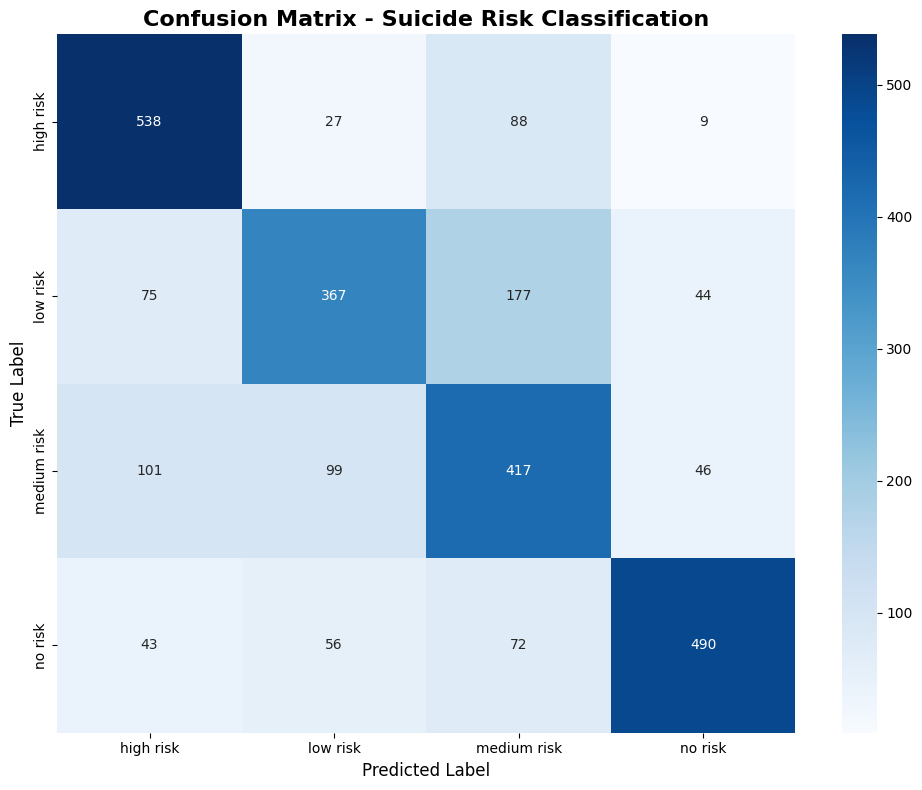

✅ Saved: confusion_matrix.png


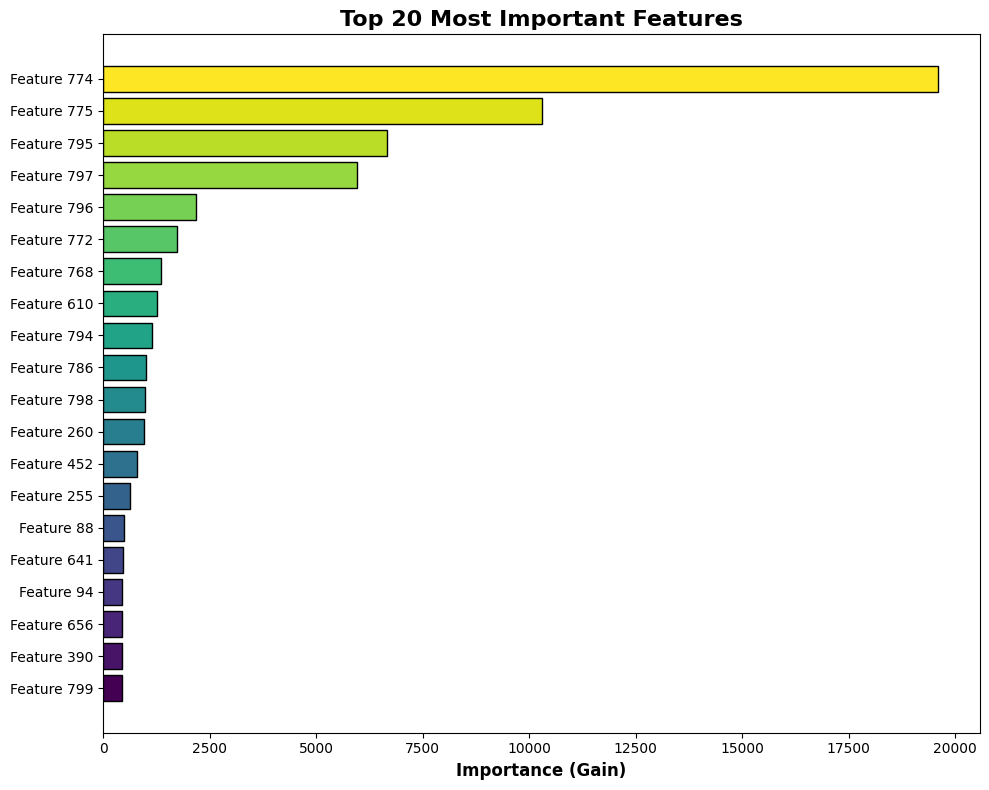

✅ Saved: feature_importance.png


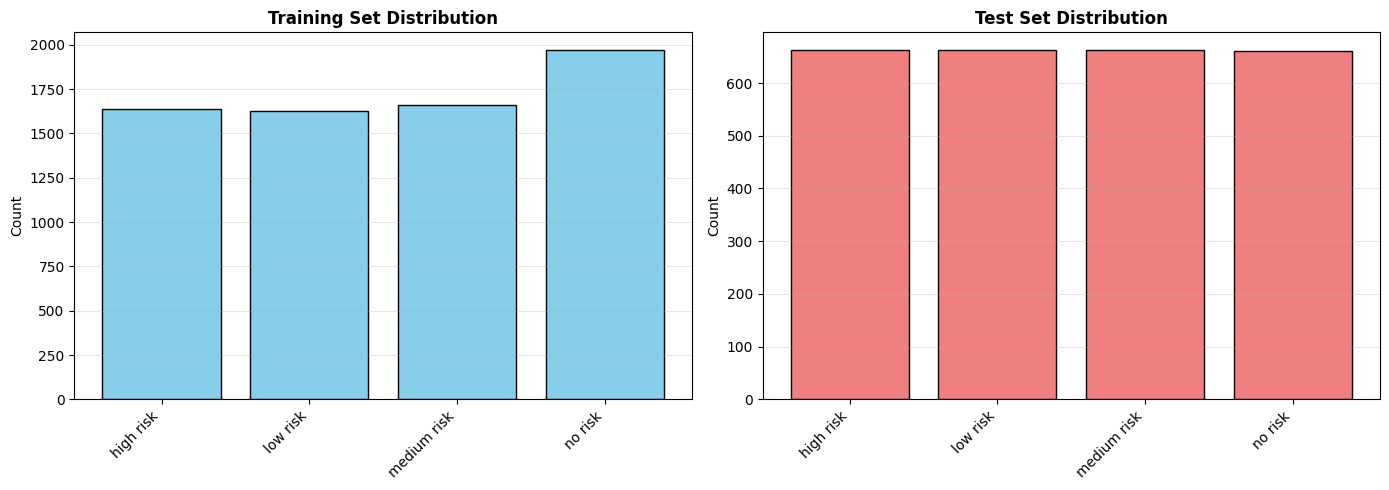

✅ Saved: class_distribution.png

💾 Saving model...
✅ Model saved to model_artifacts/pipeline.pkl

🧪 TESTING SAMPLE PREDICTIONS
📊 Generating transformer embeddings...
😊 Extracting sentiment features...
📝 Extracting linguistic features...
🏷️  Extracting POS tag features...
📚 Extracting topic features (LDA with 10 topics)...
🧠 Extracting cognitive network features...

📝 Text: I have a plan to end my life. I feel completely hopeless and alone.
🎯 Risk: high risk
📊 Probabilities:
   high risk    [███████████████████████████   ] 0.909 (90.9%)
   medium risk  [█                             ] 0.053 (5.3%)
   low risk     [                              ] 0.029 (2.9%)
   no risk      [                              ] 0.009 (0.9%)
📊 Generating transformer embeddings...
😊 Extracting sentiment features...
📝 Extracting linguistic features...
🏷️  Extracting POS tag features...
📚 Extracting topic features (LDA with 10 topics)...
🧠 Extracting cognitive network features...

📝 Text: Feeling sad today but I

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download complete!


In [ ]:
# EXECUTION
# =======================================================================
print("\n" + "="*60)
print("🎬 STARTING PIPELINE EXECUTION")
print("="*60)

# Load data
df = pd.read_csv(dataset_filename)
print(f"✅ Loaded {len(df)} samples\n")

# Run pipeline
pipeline = SuicideRiskPipeline()
results = pipeline.run_full_pipeline(df, text_col=text_column, label_col=label_column)

# Test predictions
print("\n" + "="*60)
print("🧪 TESTING SAMPLE PREDICTIONS")
print("="*60)

test_texts = [
    "I have a plan to end my life. I feel completely hopeless and alone.",
    "Feeling sad today but I'm seeing my therapist this week.",
    "Had an amazing day! Life is good right now.",
    "Sometimes I think about death but I would never do anything.",
    "Nobody would miss me if I was gone. I can't take this anymore.",
    "Managing my depression with therapy and medication."
]

for text in test_texts:
    result = pipeline.predict_text(text)
    print(f"\n📝 Text: {text}")
    print(f"🎯 Risk: {result['predicted_risk']}")
    print(f"📊 Probabilities:")
    for cls, prob in sorted(result['probabilities'].items(),
                           key=lambda x: x[1], reverse=True):
        bar = '█' * int(prob * 30)
        print(f"   {cls:12s} [{bar:<30s}] {prob:.3f} ({prob*100:.1f}%)")

print("\n" + "="*60)
print("✅ PIPELINE COMPLETE!")
print("="*60)
print(f"""
📦 Generated Files:
   ✓ confusion_matrix.png
   ✓ feature_importance.png
   ✓ class_distribution.png
   ✓ model_artifacts/pipeline.pkl

📊 Final Metrics:
   F1 Macro:     {results['f1_macro']:.4f}
   F1 Weighted:  {results['f1_weighted']:.4f}
   Balanced Acc: {results['balanced_accuracy']:.4f}

⚠️  IMPORTANT: Research/educational purposes only.
   Consult mental health professionals for real applications.
""")

# Download results
print("\n📥 Preparing download...")
import zipfile
zip_filename = 'suicide_risk_results.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in ['confusion_matrix.png', 'feature_importance.png',
                 'class_distribution.png']:
        try:
            zipf.write(file)
        except:
            pass
    if Path('model_artifacts').exists():
        for file in Path('model_artifacts').glob('*'):
            zipf.write(file)

print(f"✅ Created {zip_filename}")
files.download(zip_filename)
print("✅ Download complete!")

In [ ]:
# LOAD SAVED PIPELINE AND MAKE PREDICTIONS
# =======================================================================
import pickle
from pathlib import Path
import zipfile
import os

print("\n" + "="*60)
print("🔄 LOADING SAVED PIPELINE AND TESTING PREDICTIONS")
print("="*60)

# Define the path to the downloaded zip file and the pipeline file within it
zip_filename = 'suicide_risk_results.zip'
pipeline_path_in_zip = 'model_artifacts/pipeline.pkl'
extracted_dir = 'extracted_artifacts' # Directory to extract to

# Check if the zip file exists
if Path(zip_filename).exists():
    print(f"✅ Found zip file: {zip_filename}")

    # Create extraction directory if it doesn't exist
    Path(extracted_dir).mkdir(exist_ok=True)

    # Extract the pipeline file from the zip
    try:
        with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
            # Extract only the pipeline file
            zip_ref.extract(pipeline_path_in_zip, extracted_dir)
        print(f"✅ Extracted {pipeline_path_in_zip} to {extracted_dir}")

        # Define the full path to the extracted pipeline file
        extracted_pipeline_path = Path(extracted_dir) / pipeline_path_in_zip

        # Load the pipeline
        with open(extracted_pipeline_path, 'rb') as f:
            loaded_pipeline = pickle.load(f)
        print(f"✅ Pipeline loaded from {extracted_pipeline_path}")

        # Test predictions with the loaded pipeline
        test_texts_new = [
            "I feel completely lost and don't see a way out.",
            "Had a tough day at work, but I'll be okay.",
            "Thinking about giving up.",
            "Spent time with friends today, feeling much better.",
            "i'm planning to die today by hanging myself"
        ]

        for text in test_texts_new:
            result = loaded_pipeline.predict_text(text)
            print(f"\n📝 Text: {text}")
            print(f"🎯 Risk: {result['predicted_risk']}")
            print(f"📊 Probabilities:")
            for cls, prob in sorted(result['probabilities'].items(),
                                   key=lambda x: x[1], reverse=True):
                bar = '█' * int(prob * 30)
                print(f"   {cls:12s} [{bar:<30s}] {prob:.3f} ({prob*100:.1f}%)")

    except FileNotFoundError:
        print(f"❌ Could not find '{pipeline_path_in_zip}' inside '{zip_filename}'.")
    except Exception as e:
        print(f"❌ An error occurred during extraction or loading: {e}")

else:
    print(f"❌ Zip file '{zip_filename}' not found. Please make sure it's in the current directory.")


print("\n" + "="*60)
print("✅ PREDICTION TESTING COMPLETE!")
print("="*60)


🔄 LOADING SAVED PIPELINE AND TESTING PREDICTIONS
✅ Found zip file: suicide_risk_results.zip
✅ Extracted model_artifacts/pipeline.pkl to extracted_artifacts
✅ Pipeline loaded from extracted_artifacts/model_artifacts/pipeline.pkl
📊 Generating transformer embeddings...
😊 Extracting sentiment features...
📝 Extracting linguistic features...
🏷️  Extracting POS tag features...
📚 Extracting topic features (LDA with 10 topics)...
🧠 Extracting cognitive network features...

📝 Text: I feel completely lost and don't see a way out.
🎯 Risk: no risk
📊 Probabilities:
   no risk      [███████████████████           ] 0.643 (64.3%)
   medium risk  [█████████                     ] 0.324 (32.4%)
   low risk     [                              ] 0.027 (2.7%)
   high risk    [                              ] 0.005 (0.5%)
📊 Generating transformer embeddings...
😊 Extracting sentiment features...
📝 Extracting linguistic features...
🏷️  Extracting POS tag features...
📚 Extracting topic features (LDA with 10 topic

In [ ]:
# =======================================================================
# STEP 1: INSTALL REQUIRED LIBRARIES
# =======================================================================
!pip install -q sentence-transformers gensim vaderSentiment networkx spacy lightgbm numpy==1.26.4 pandas==2.2.2 scikit-learn==1.2.2
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 88.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# =======================================================================
# LOAD SAVED MODEL AND TEST NEW SAMPLES
# Upload your saved model_artifacts folder and run this code
# =======================================================================


# =======================================================================
# STEP 2: UPLOAD MODEL FILES
# =======================================================================
from google.colab import files
import zipfile
import os

print("📂 Please upload your 'suicide_risk_results.zip' file:")
uploaded = files.upload()

# Extract the zip file
zip_filename = list(uploaded.keys())[0]
print(f"\n📦 Extracting {zip_filename}...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('.')
print("✅ Files extracted successfully!\n")

# =======================================================================
# STEP 3: IMPORT LIBRARIES
# =======================================================================
import warnings
warnings.filterwarnings('ignore')

import pickle
import pandas as pd
import numpy as np
import re
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sentence_transformers import SentenceTransformer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from gensim import corpora
from gensim.models import LdaModel
import networkx as nx

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

print("✅ All libraries imported!\n")

# =======================================================================
# STEP 4: LOAD THE SAVED PIPELINE
# =======================================================================
print("📥 Loading saved model...")
try:
    with open('model_artifacts/pipeline.pkl', 'rb') as f:
        pipeline = pickle.load(f)
    print("✅ Model loaded successfully!\n")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    print("\n💡 Make sure 'model_artifacts/pipeline.pkl' exists in the extracted files.")
    raise

# =======================================================================
# STEP 5: QUICK PREDICTION FUNCTION
# =======================================================================
def predict_risk(text, show_details=True):
    """
    Predict suicide risk level for a given text

    Args:
        text (str): Input text to analyze
        show_details (bool): Show detailed probability breakdown

    Returns:
        dict: Prediction results
    """
    result = pipeline.predict_text(text)

    if show_details:
        print("="*70)
        print(f"📝 Input Text:")
        print(f"   {text}")
        print("-"*70)
        print(f"🎯 Predicted Risk Level: {result['predicted_risk'].upper()}")
        print("-"*70)
        print("📊 Risk Probabilities:")

        # Sort by probability (highest first)
        sorted_probs = sorted(result['probabilities'].items(),
                             key=lambda x: x[1], reverse=True)

        for risk_level, prob in sorted_probs:
            # Create visual bar
            bar_length = int(prob * 40)
            bar = '█' * bar_length + '░' * (40 - bar_length)

            # Color coding (for display)
            if prob > 0.5:
                indicator = "🔴" if "high" in risk_level else "🟢" if "no" in risk_level else "🟡"
            else:
                indicator = "  "

            print(f"{indicator} {risk_level:12s} [{bar}] {prob:.4f} ({prob*100:.1f}%)")
        print("="*70)
        print()

    return result

# =======================================================================
# STEP 6: BATCH PREDICTION FUNCTION
# =======================================================================
def predict_batch(texts, save_to_csv=False):
    """
    Predict risk levels for multiple texts

    Args:
        texts (list): List of text strings
        save_to_csv (bool): Save results to CSV file

    Returns:
        DataFrame: Results with predictions
    """
    print(f"🔄 Processing {len(texts)} texts...\n")

    results = []
    for idx, text in enumerate(texts, 1):
        print(f"Processing {idx}/{len(texts)}...", end='\r')
        pred = pipeline.predict_text(text)

        results.append({
            'text': text,
            'predicted_risk': pred['predicted_risk'],
            'high_risk_prob': pred['probabilities'].get('high risk', 0),
            'medium_risk_prob': pred['probabilities'].get('medium risk', 0),
            'low_risk_prob': pred['probabilities'].get('low risk', 0),
            'no_risk_prob': pred['probabilities'].get('no risk', 0)
        })

    df_results = pd.DataFrame(results)
    print("\n✅ Batch processing complete!\n")

    # Display summary
    print("📊 Prediction Summary:")
    print(df_results['predicted_risk'].value_counts())
    print()

    if save_to_csv:
        df_results.to_csv('predictions.csv', index=False)
        print("💾 Results saved to 'predictions.csv'\n")

    return df_results

# =======================================================================
# STEP 7: INTERACTIVE TESTING
# =======================================================================
def interactive_test():
    """Interactive testing mode - keep entering texts"""
    print("\n🔬 INTERACTIVE TESTING MODE")
    print("="*70)
    print("Enter text to analyze (or 'quit' to exit)")
    print("="*70)

    while True:
        text = input("\n📝 Enter text: ").strip()

        if text.lower() in ['quit', 'exit', 'q']:
            print("👋 Exiting interactive mode.")
            break

        if not text:
            print("⚠️  Please enter some text.")
            continue

        predict_risk(text, show_details=True)

# =======================================================================
# STEP 8: TEST WITH SAMPLE TEXTS
# =======================================================================
print("🧪 TESTING WITH SAMPLE TEXTS")
print("="*70)
print()

sample_texts = [
    "I have a detailed plan to end my life tonight. I've written goodbye letters.",
    "Feeling a bit down today but I'm managing with therapy.",
    "Just had the best day ever! Life is amazing right now!",
    "Sometimes I think about death but I would never actually do it.",
    "I can't take this pain anymore. Nobody would miss me if I was gone.",
    "Struggling with anxiety but my support system is helping me.",
    "I feel hopeless and worthless. Everything seems pointless.",
    "Had a productive therapy session today. Feeling more optimistic."
]

print(f"Running predictions on {len(sample_texts)} sample texts...\n")

for i, text in enumerate(sample_texts, 1):
    print(f"\n{'='*70}")
    print(f"SAMPLE {i}/{len(sample_texts)}")
    predict_risk(text, show_details=True)

# =======================================================================
# STEP 9: USAGE EXAMPLES
# =======================================================================
print("\n" + "="*70)
print("📚 USAGE EXAMPLES")
print("="*70)
print("""
# Example 1: Test a single text
text = "I feel so hopeless and want to end everything"
result = predict_risk(text)

# Example 2: Test multiple texts
texts = [
    "I'm feeling better today",
    "I have a suicide plan",
    "Life is good right now"
]
df_results = predict_batch(texts, save_to_csv=True)
print(df_results)

# Example 3: Interactive mode
interactive_test()

# Example 4: Get just the prediction (no printing)
result = predict_risk("your text here", show_details=False)
print(result['predicted_risk'])
print(result['probabilities'])
""")

# =======================================================================
# STEP 10: READY FOR YOUR TESTS
# =======================================================================
print("\n" + "="*70)
print("✅ MODEL READY FOR TESTING!")
print("="*70)
print("""
Choose an option:

1️⃣  Test your own text:
   predict_risk("your text here")

2️⃣  Batch test multiple texts:
   my_texts = ["text 1", "text 2", "text 3"]
   predict_batch(my_texts, save_to_csv=True)

3️⃣  Interactive mode:
   interactive_test()

4️⃣  Quick test:
   result = predict_risk("I feel hopeless", show_details=False)
   print(result)
""")

# =======================================================================
# OPTIONAL: START INTERACTIVE MODE AUTOMATICALLY
# =======================================================================
# Uncomment the line below to start interactive mode immediately:
# interactive_test()

📂 Please upload your 'suicide_risk_results.zip' file:


Saving suicide_risk_results.zip to suicide_risk_results.zip

📦 Extracting suicide_risk_results.zip...
✅ Files extracted successfully!

✅ All libraries imported!

📥 Loading saved model...
❌ Error loading model: Can't get attribute 'SuicideRiskPipeline' on <module '__main__'>

💡 Make sure 'model_artifacts/pipeline.pkl' exists in the extracted files.


AttributeError: Can't get attribute 'SuicideRiskPipeline' on <module '__main__'>